# Session 24: Very Basic Introduction to Deep Learning
### Duration: ~2-2.5 Hours

---

## Session Goal
This session is a gentle bridge from classical machine learning to deep learning.

Students have already learned:
- Loading and exploring data with pandas
- Train/test split
- Scaling data
- Classification models
- Accuracy, confusion matrix, and classification report
- Model comparison

Today we introduce a new kind of model: a **neural network**.

## Big Idea
Deep learning is still machine learning.

The workflow is familiar:

```text
Data -> Train/Test Split -> Preprocessing -> Model Training -> Evaluation -> Prediction
```

The difference is the model structure. Neural networks learn using connected layers of small mathematical units called **neurons**.

## Dataset
We will use the famous **Iris dataset** because it is small, clean, and easy to understand.

Task:
> Predict the Iris flower species using sepal and petal measurements.

This keeps the first deep learning class focused on concepts, not complicated data cleaning.

---
## 1. Important Deep Learning Vocabulary

### Machine Learning vs Deep Learning

Classical ML models we have seen:
- Logistic Regression
- Decision Trees
- Random Forest
- KMeans

Deep learning models:
- Neural Networks
- Convolutional Neural Networks for images
- Recurrent Neural Networks for sequences
- Transformers for text and modern AI systems

For today, we only learn the simplest version: a **feed-forward neural network**.

### Neural Network Structure

A basic neural network has:

```text
Input Layer -> Hidden Layer(s) -> Output Layer
```

For Iris:

```text
Input layer: 4 measurements
Hidden layer: neurons that learn patterns
Output layer: 3 flower species
```

### Neuron
A neuron takes input values, multiplies them by weights, adds a bias, and passes the result through an activation function.

Simple idea:

```text
z = w1*x1 + w2*x2 + w3*x3 + ... + b
```

### Activation Function
An activation function helps the network learn non-linear patterns.

Today we use:
- `relu` inside the network
- `softmax` idea for multi-class probabilities, handled internally by scikit-learn

### Epoch
One epoch means the model has gone through the training data once.

### Loss
Loss tells the model how wrong it is. During training, the neural network tries to reduce loss.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', palette='colorblind')

RANDOM_STATE = 42
OUTPUT_DIR = Path('session24_artifacts')
OUTPUT_DIR.mkdir(exist_ok=True)

print('Environment ready.')

Environment ready.


---
## 2. Load the Iris Dataset

The Iris dataset has 150 rows and 4 input features:

- `sepal length (cm)`
- `sepal width (cm)`
- `petal length (cm)`
- `petal width (cm)`

The target has 3 classes:

- Setosa
- Versicolor
- Virginica

In [2]:
iris = load_iris(as_frame=True)

X = iris.data.copy()
y = iris.target.copy()

flower_names = dict(enumerate(iris.target_names))
df = X.copy()
df['species_id'] = y
df['species'] = df['species_id'].map(flower_names)

print('Feature shape:', X.shape)
print('Target shape:', y.shape)
print('Class names:', iris.target_names.tolist())

df.head()

Feature shape: (150, 4)
Target shape: (150,)
Class names: ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [3]:
print('Dataset information:')
df.info()

print('\nClass distribution:')
print(df['species'].value_counts())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species_id         150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB

Class distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


---
## 3. Quick EDA

Even when using neural networks, we still explore the data first.

Deep learning does not remove the need for data understanding.

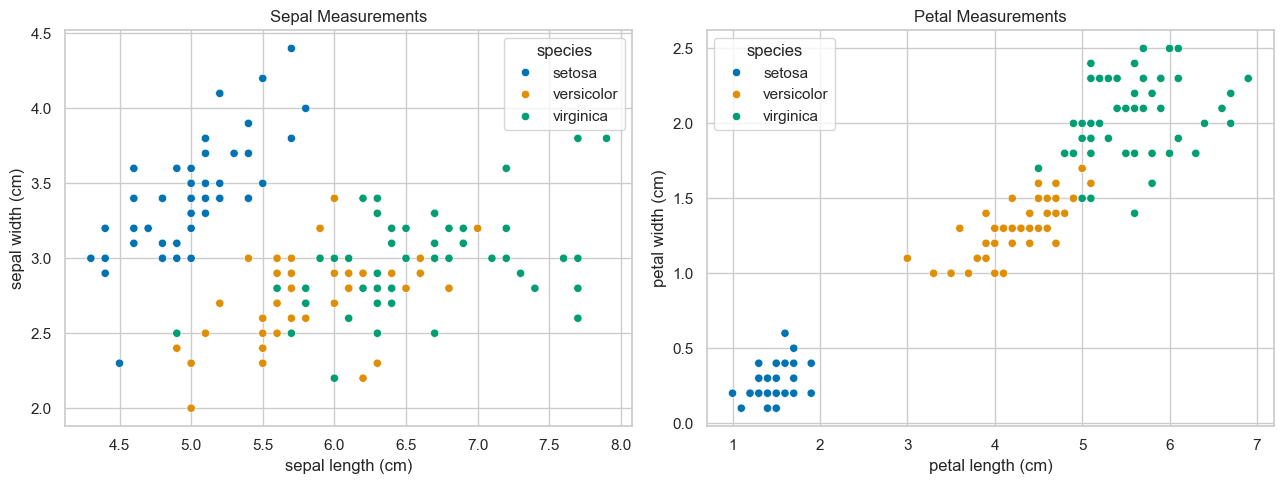

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    data=df,
    x='sepal length (cm)',
    y='sepal width (cm)',
    hue='species',
    ax=axes[0],
)
axes[0].set_title('Sepal Measurements')

sns.scatterplot(
    data=df,
    x='petal length (cm)',
    y='petal width (cm)',
    hue='species',
    ax=axes[1],
)
axes[1].set_title('Petal Measurements')

plt.tight_layout()
plt.show()

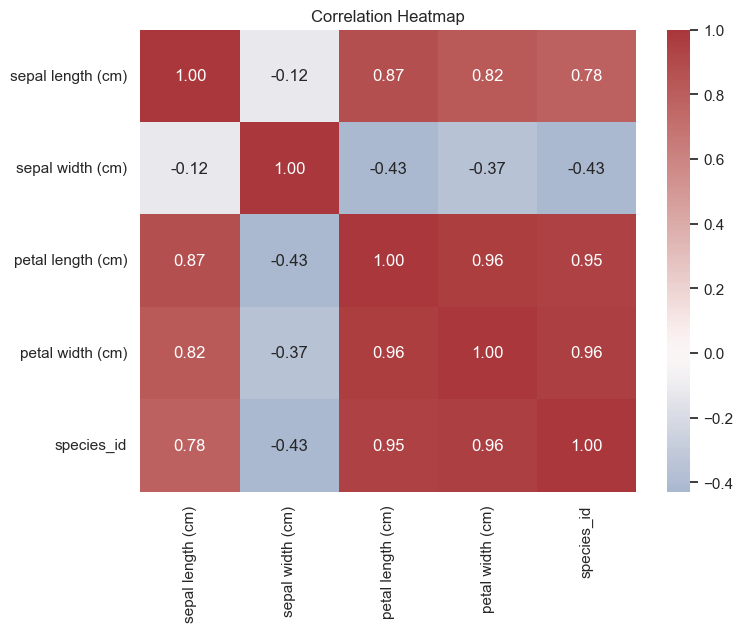

In [5]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.drop(columns=['species']).corr(), annot=True, cmap='vlag', center=0, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

---
## 4. Train-Test Split

This part is exactly like our earlier ML workflow.

We split the data so that the model is tested on examples it did not see during training.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])
print('\nTraining class distribution:')
print(y_train.map(flower_names).value_counts())
print('\nTest class distribution:')
print(y_test.map(flower_names).value_counts())

Training rows: 112
Test rows: 38

Training class distribution:
target
setosa        38
virginica     37
versicolor    37
Name: count, dtype: int64

Test class distribution:
target
versicolor    13
virginica     13
setosa        12
Name: count, dtype: int64


---
## 5. Why Scaling Matters More for Neural Networks

Neural networks learn by adjusting weights gradually.

If one feature has much larger values than another feature, training can become harder.

So we use `StandardScaler` before the neural network.

This converts features to a similar scale.

In [7]:
scaler_demo = StandardScaler()
X_train_scaled_demo = scaler_demo.fit_transform(X_train)

scaled_preview = pd.DataFrame(X_train_scaled_demo, columns=X_train.columns).head()
scaled_preview

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,1.792138,-0.602380,1.315323,0.920954
1,2.145311,-0.602380,1.653204,1.051355
2,-0.444618,-1.507973,-0.036202,-0.252651
3,0.261726,-0.602380,0.132739,0.138551
4,-0.444618,-1.281575,0.132739,0.138551


---
## 6. Classical ML Baseline: Logistic Regression

Before using a neural network, we train a familiar model.

This helps students understand an important point:

> Deep learning is powerful, but it is not always necessary for small tabular datasets.

In [8]:
logistic_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

logistic_model.fit(X_train, y_train)
logistic_pred = logistic_model.predict(X_test)

logistic_accuracy = accuracy_score(y_test, logistic_pred)
print('Logistic Regression accuracy:', round(logistic_accuracy, 4))
print('\nClassification report:')
print(classification_report(y_test, logistic_pred, target_names=iris.target_names))

Logistic Regression accuracy: 0.9211

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       0.86      0.92      0.89        13
   virginica       0.92      0.85      0.88        13

    accuracy                           0.92        38
   macro avg       0.92      0.92      0.92        38
weighted avg       0.92      0.92      0.92        38



---
## 7. Build Our First Neural Network

We will use scikit-learn's `MLPClassifier`.

`MLP` means **Multi-Layer Perceptron**.

This is a basic feed-forward neural network.

Our network:

```text
Input: 4 Iris measurements
Hidden layer 1: 8 neurons
Output: 3 species probabilities
```

In scikit-learn, the output layer is handled automatically based on the number of target classes.

In [9]:
neural_net = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', MLPClassifier(
        hidden_layer_sizes=(8,),
        activation='relu',
        solver='adam',
        learning_rate_init=0.01,
        max_iter=500,
        random_state=RANDOM_STATE,
    )),
])

neural_net.fit(X_train, y_train)

nn_pred = neural_net.predict(X_test)
nn_accuracy = accuracy_score(y_test, nn_pred)

print('Neural Network accuracy:', round(nn_accuracy, 4))
print('\nClassification report:')
print(classification_report(y_test, nn_pred, target_names=iris.target_names))

Neural Network accuracy: 0.9737

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        12
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



---
## 8. Understand the Network Settings

Important settings in `MLPClassifier`:

### `hidden_layer_sizes=(8,)`
This means one hidden layer with 8 neurons.

### `activation='relu'`
ReLU helps the network learn non-linear patterns.

### `solver='adam'`
Adam is an optimizer. It updates the weights during training.

### `learning_rate_init=0.01`
Learning rate controls how large each weight update is.

### `max_iter=500`
Maximum number of training iterations.

Do not worry about mastering all settings today. The goal is to understand the idea.

---
## 9. Visualize Training Loss

The neural network trains by trying to reduce loss.

If loss goes down, the model is learning from the training data.

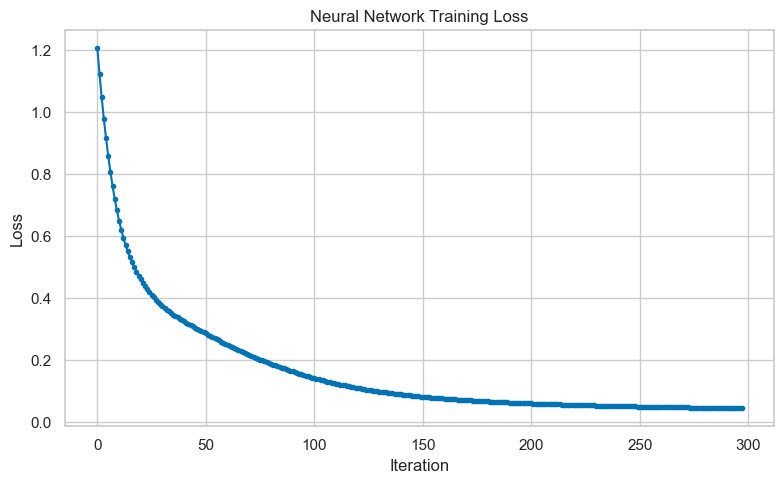

Number of training iterations: 298
Final training loss: 0.0449


In [10]:
mlp = neural_net.named_steps['classifier']

plt.figure(figsize=(8, 5))
plt.plot(mlp.loss_curve_, marker='o', markersize=3)
plt.title('Neural Network Training Loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

print('Number of training iterations:', mlp.n_iter_)
print('Final training loss:', round(mlp.loss_, 4))

---
## 10. Confusion Matrix

The confusion matrix shows where the model predicted correctly and incorrectly.

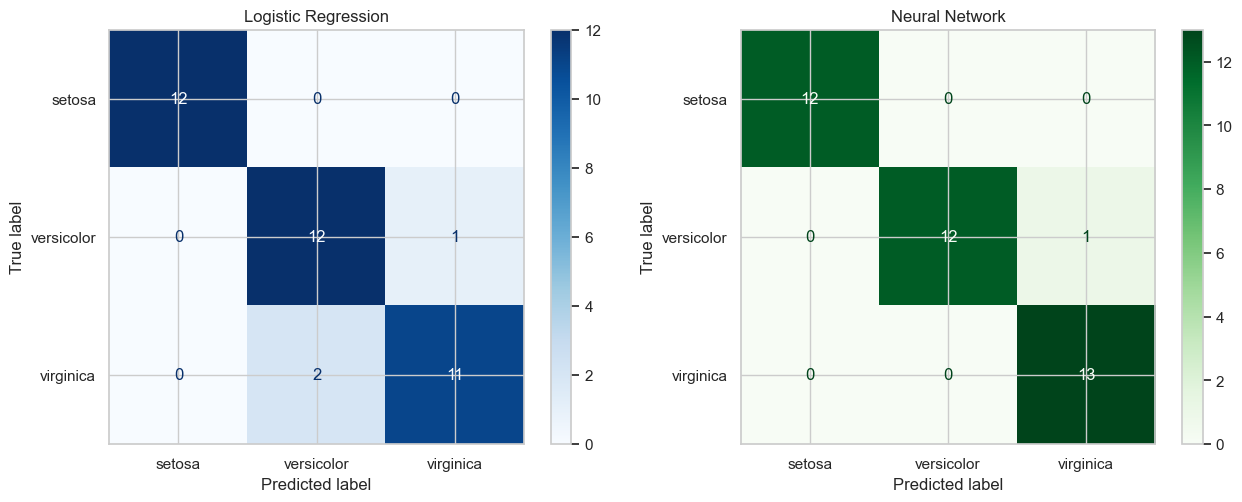

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_estimator(
    logistic_model,
    X_test,
    y_test,
    display_labels=iris.target_names,
    cmap='Blues',
    ax=axes[0],
)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay.from_estimator(
    neural_net,
    X_test,
    y_test,
    display_labels=iris.target_names,
    cmap='Greens',
    ax=axes[1],
)
axes[1].set_title('Neural Network')

plt.tight_layout()
plt.show()

---
## 11. Compare Classical ML and Neural Network

For this small dataset, both models can perform very well.

That is an important lesson:

> Deep learning is not automatically better. It is most useful when the data or pattern is complex enough to need it.

In [12]:
comparison = pd.DataFrame({
    'model': ['Logistic Regression', 'Small Neural Network'],
    'accuracy': [logistic_accuracy, nn_accuracy],
})

comparison

,model,accuracy
0,Logistic Regression,0.921053
1,Small Neural Network,0.973684


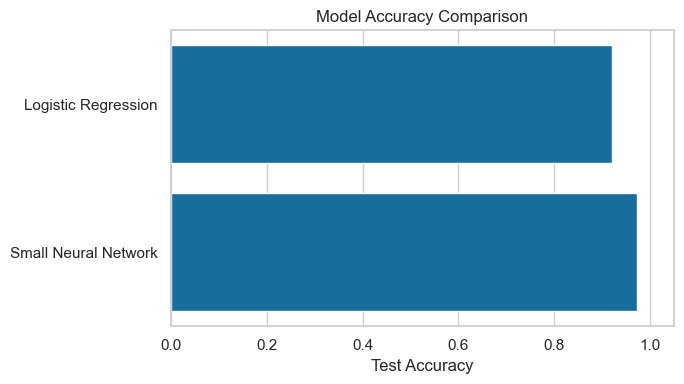

In [13]:
plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x='accuracy', y='model')
plt.xlim(0, 1.05)
plt.title('Model Accuracy Comparison')
plt.xlabel('Test Accuracy')
plt.ylabel('')
plt.tight_layout()
plt.show()

---
## 12. Make New Predictions

Let us pretend we measured a new flower.

The model will predict the species.

In [14]:
new_flower = pd.DataFrame({
    'sepal length (cm)': [5.8],
    'sepal width (cm)': [2.7],
    'petal length (cm)': [4.1],
    'petal width (cm)': [1.0],
})

predicted_class = neural_net.predict(new_flower)[0]
predicted_probabilities = neural_net.predict_proba(new_flower)[0]

print('Predicted species:', flower_names[predicted_class])
print('\nPrediction probabilities:')
for class_name, probability in zip(iris.target_names, predicted_probabilities):
    print(f'{class_name}: {probability:.3f}')

Predicted species: versicolor

Prediction probabilities:
setosa: 0.000
versicolor: 1.000
virginica: 0.000


---
## 13. Experiment: Change the Network Size

Let us compare three neural networks:

1. Very small: 2 neurons
2. Small: 8 neurons
3. Bigger: 16 and 8 neurons

This shows that architecture is a design choice.

In [15]:
network_configs = {
    '1 hidden layer, 2 neurons': (2,),
    '1 hidden layer, 8 neurons': (8,),
    '2 hidden layers, 16 and 8 neurons': (16, 8),
}

experiment_results = []

for name, hidden_layers in network_configs.items():
    model = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('classifier', MLPClassifier(
            hidden_layer_sizes=hidden_layers,
            activation='relu',
            solver='adam',
            learning_rate_init=0.01,
            max_iter=500,
            random_state=RANDOM_STATE,
        )),
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    experiment_results.append({
        'network': name,
        'hidden_layer_sizes': hidden_layers,
        'test_accuracy': accuracy_score(y_test, preds),
        'final_loss': model.named_steps['classifier'].loss_,
        'iterations': model.named_steps['classifier'].n_iter_,
    })

experiment_df = pd.DataFrame(experiment_results)
experiment_df

,network,hidden_layer_sizes,test_accuracy,final_loss,iterations
0,"1 hidden layer, 2 neurons","(2,)",0.973684,0.182242,500
1,"1 hidden layer, 8 neurons","(8,)",0.973684,0.044894,298
2,"2 hidden layers, 16 and 8 neurons","(16, 8)",0.947368,0.035082,127


---
## 14. Save the Neural Network Model

Just like previous ML models, a neural network model can be saved and reused later.

In [16]:
model_path = OUTPUT_DIR / 'iris_basic_neural_network.joblib'
comparison_path = OUTPUT_DIR / 'model_comparison.csv'
experiment_path = OUTPUT_DIR / 'network_size_experiment.csv'

comparison.to_csv(comparison_path, index=False)
experiment_df.to_csv(experiment_path, index=False)
dump(neural_net, model_path)

print('Saved neural network model:', model_path)
print('Saved model comparison:', comparison_path)
print('Saved network experiment:', experiment_path)

Saved neural network model: session24_artifacts\iris_basic_neural_network.joblib
Saved model comparison: session24_artifacts\model_comparison.csv
Saved network experiment: session24_artifacts\network_size_experiment.csv


---
## 15. Class Discussion

Use these questions to check understanding:

1. Is deep learning a separate field from machine learning, or part of machine learning?
2. What is a neuron?
3. What is a hidden layer?
4. Why do we scale features before training a neural network?
5. What does loss mean?
6. What does it mean if training loss goes down?
7. Was the neural network much better than logistic regression here?
8. Why might deep learning become more useful for images, audio, and text?

---

## Final Summary

Today we learned that a neural network is a machine learning model made of connected layers.

The workflow still feels familiar:

```text
Load data -> Explore data -> Split data -> Scale features -> Train model -> Evaluate -> Predict -> Save model
```

The new ideas are:

- Neurons
- Weights and biases
- Hidden layers
- Activation functions
- Loss
- Optimizers
- Training iterations

Most important takeaway:

> Deep learning is powerful, but it should be used when the problem needs it. For small tabular datasets, classical ML can still be excellent.

In the next session, we can move from simple numeric data to images using Fashion MNIST.